In [1]:
import setup
from importlib import reload
reload(setup)
from setup import *
Ag_comp = 0.9

# BF

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.47,7
,3000,0,0.46,15
,3000,0,0.44,15
,3000,0,0.44,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -243.11    60.65
p_loo       14.08        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



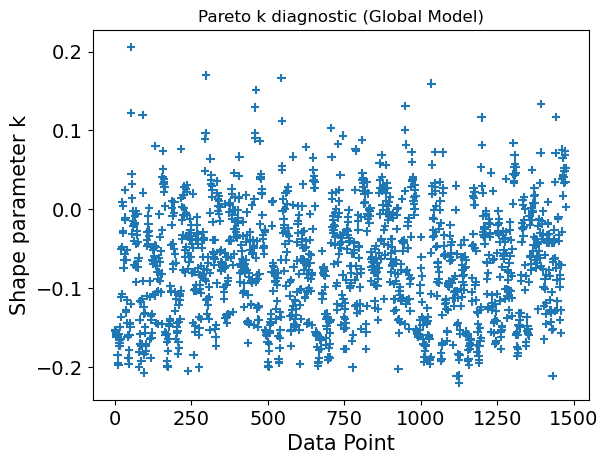

In [2]:
with pm.Model() as BF:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH# -> COOH* + # (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    rate = observables(log_rate) 

trace_BF, loo_BF = fit_and_evaluate(BF)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.072  0.001  -0.075   -0.070      0.000    0.000    1555.0    2252.0    1.0
deltaG4_0   0.130  0.003   0.124    0.136      0.000    0.000    3438.0    2741.0    1.0
deltaG5_0  -0.141  0.002  -0.146   -0.137      0.000    0.000    2448.0    2745.0    1.0
Gact2_0     0.707  0.001   0.705    0.708      0.000    0.000    1555.0    2375.0    1.0
sigma_rel   0.307  0.016   0.277    0.337      0.000    0.000    2636.0    2791.0    1.0
sigma_base  0.057  0.003   0.052    0.063      0.000    0.000    2889.0    2662.0    1.0
exponent    2.639  0.114   2.414    2.838      0.002    0.002    2502.0    2602.0    1.0


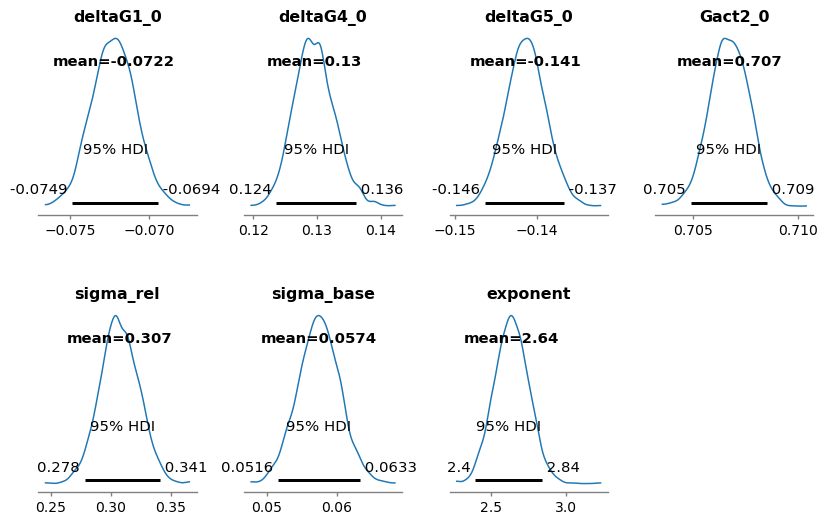

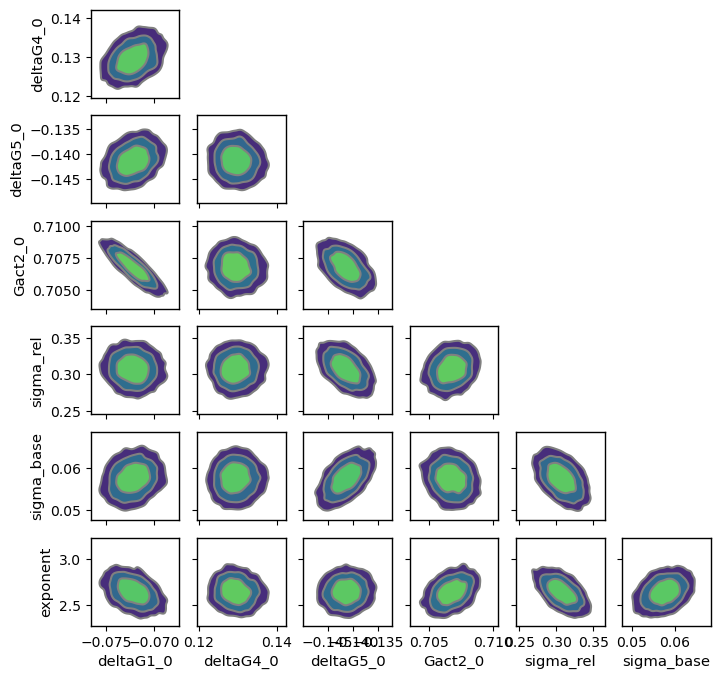

Sampling: [rate]


rate: 0.550


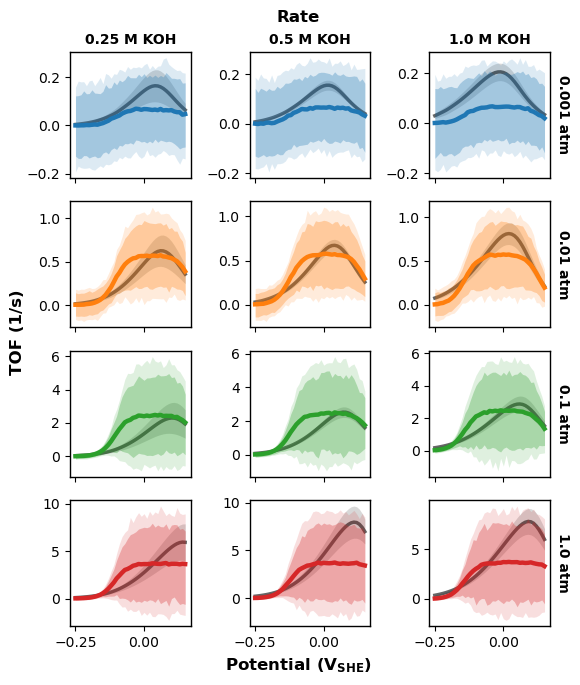

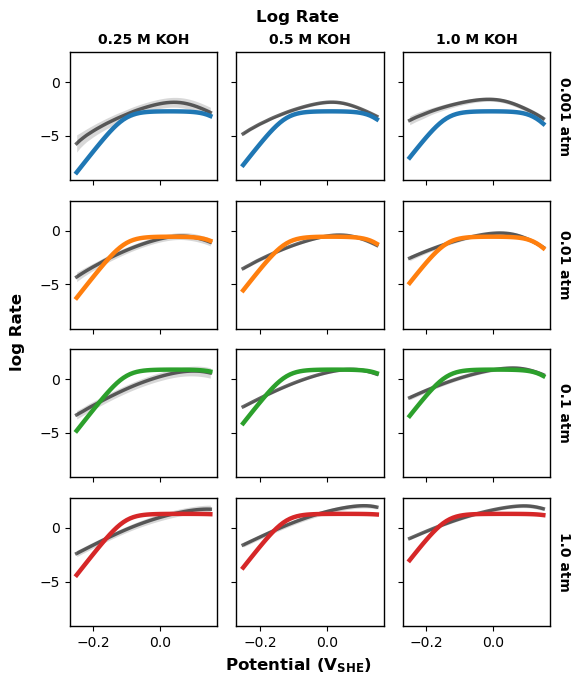

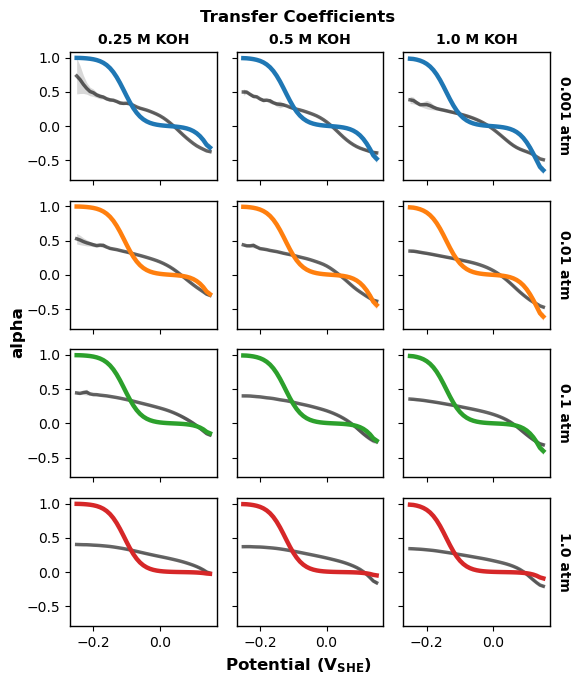

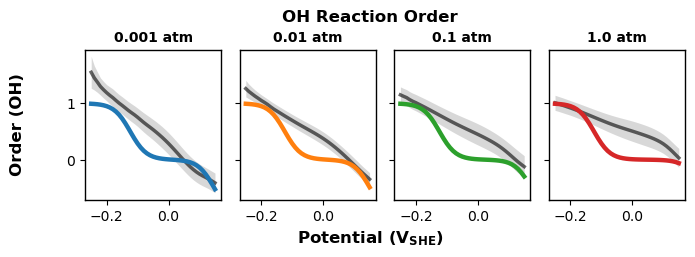

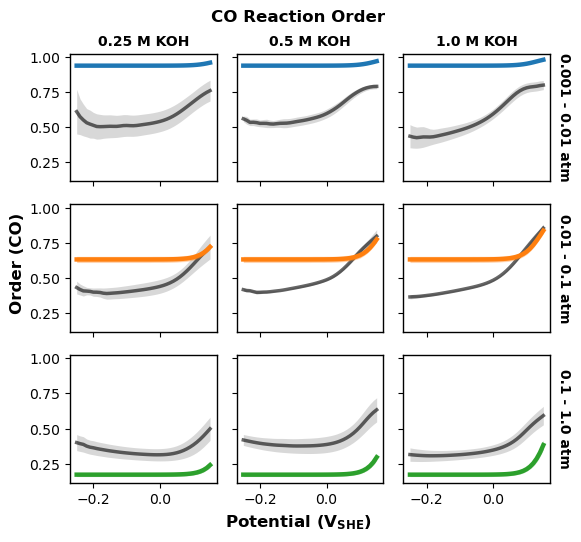

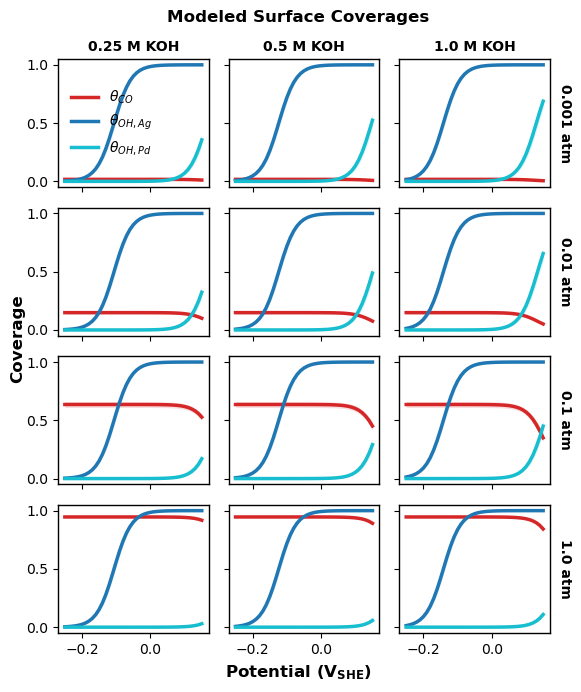

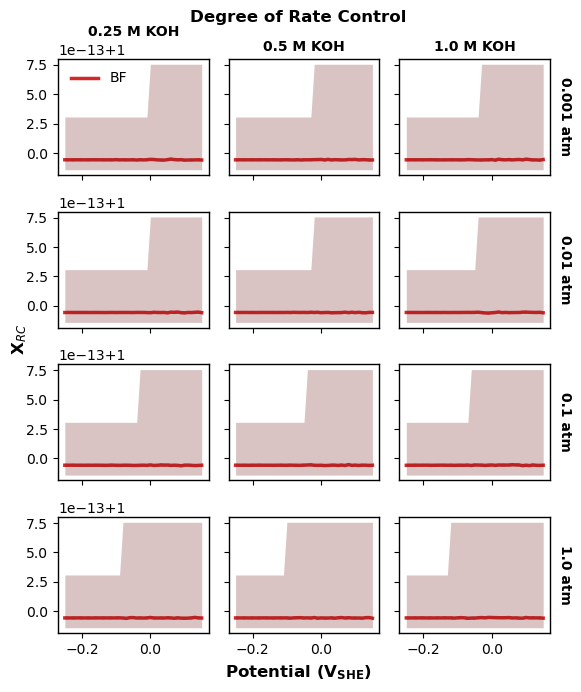

In [3]:
ppc_BF = plot_posteriors(trace_BF, BF)
plot_model_fits(trace_BF, ppc_BF); plot_coverages(trace_BF)
plot_drc(BF, trace_BF, perturb_vars=['Gact2_0'], perturb_labels=['BF'])

# ER 2 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.46,15
,3000,0,0.49,7
,3000,0,0.44,15
,3000,0,0.42,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   162.69    64.59
p_loo        9.80        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



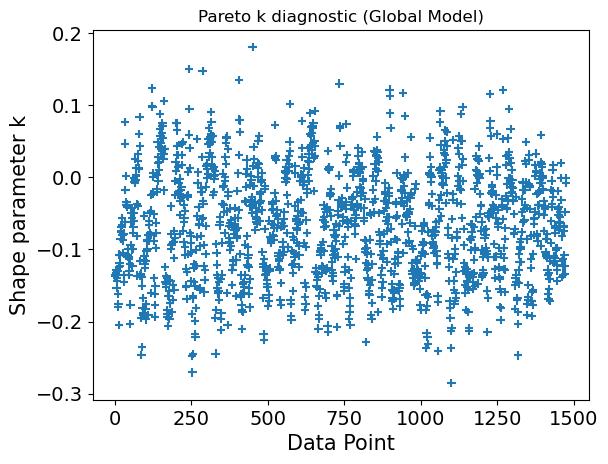

In [4]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.089  0.001  -0.091   -0.086      0.000    0.000    1721.0    2031.0    1.0
deltaG4_0   0.038  0.002   0.034    0.042      0.000    0.000    1958.0    2189.0    1.0
deltaG5_0   0.001  0.199  -0.380    0.369      0.003    0.003    5559.0    3225.0    1.0
Gact2_0     0.695  0.001   0.694    0.697      0.000    0.000    1873.0    2015.0    1.0
beta_2      0.296  0.004   0.288    0.303      0.000    0.000    2172.0    2533.0    1.0
sigma_rel   0.305  0.011   0.284    0.327      0.000    0.000    2837.0    2961.0    1.0
sigma_base  0.031  0.002   0.027    0.035      0.000    0.000    2766.0    2973.0    1.0
exponent    2.166  0.060   2.055    2.283      0.001    0.001    3401.0    2804.0    1.0


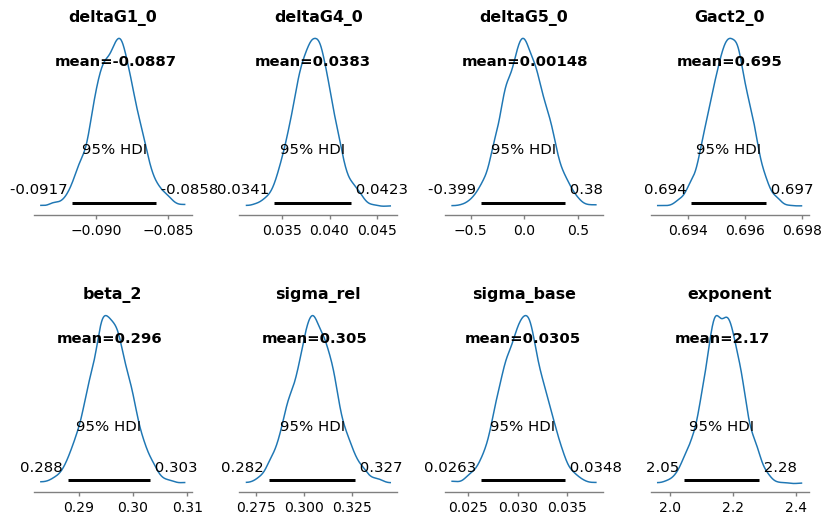

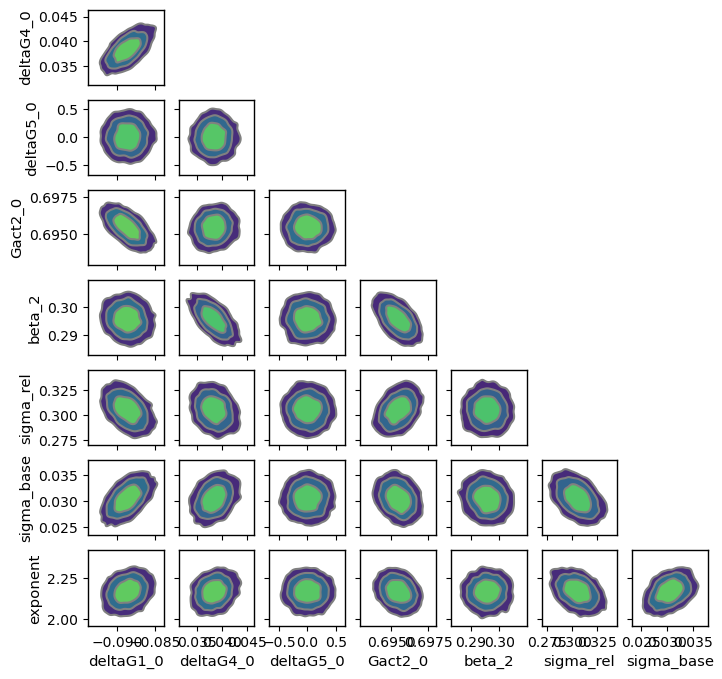

Sampling: [rate]


rate: 0.679


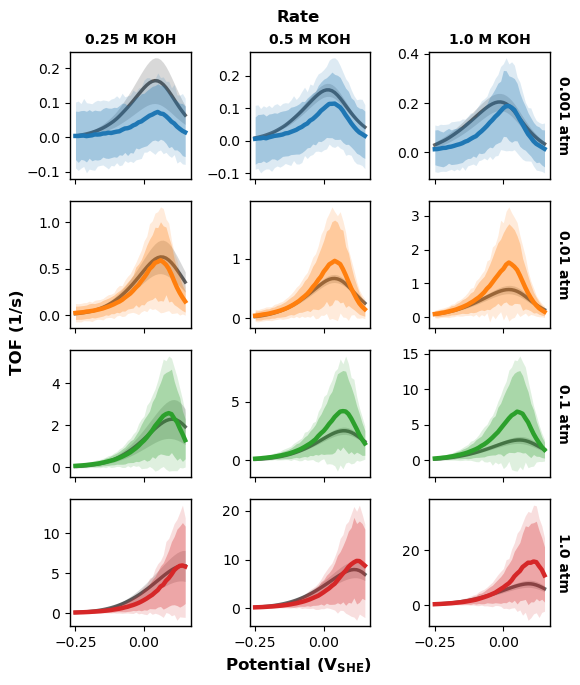

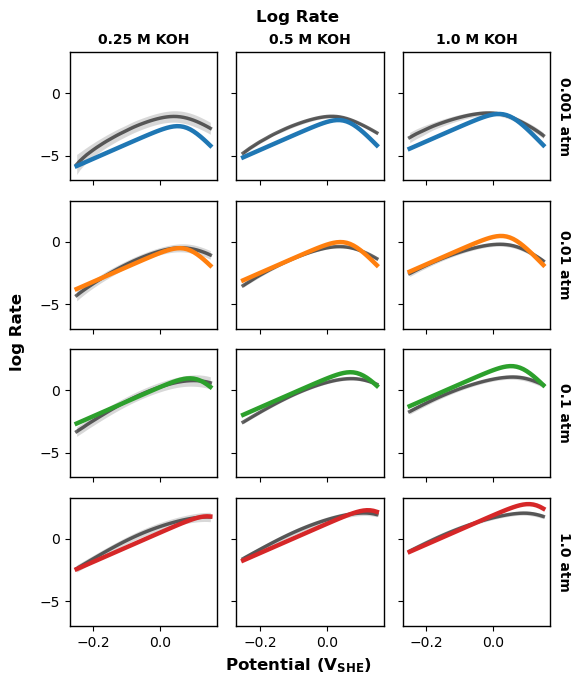

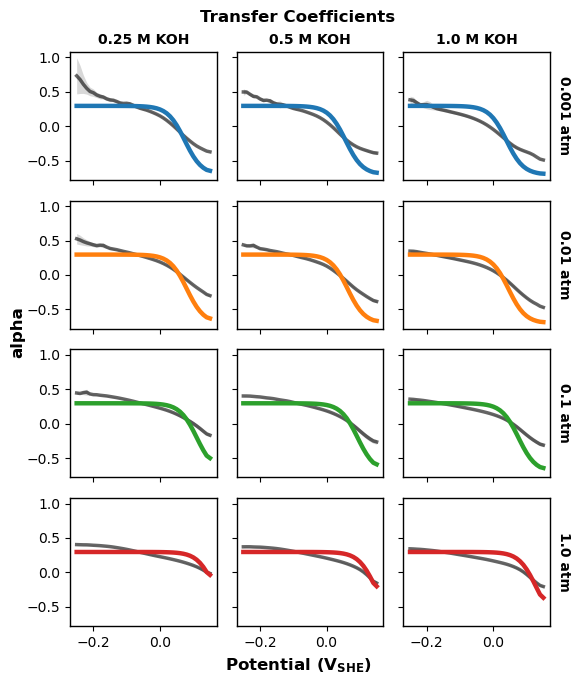

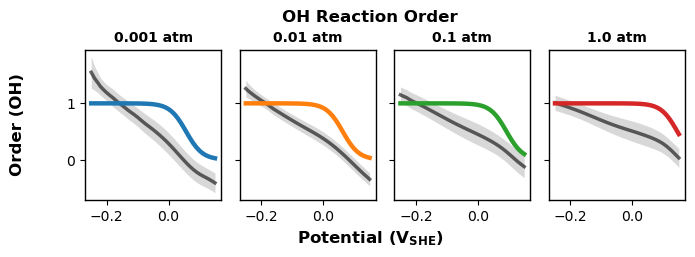

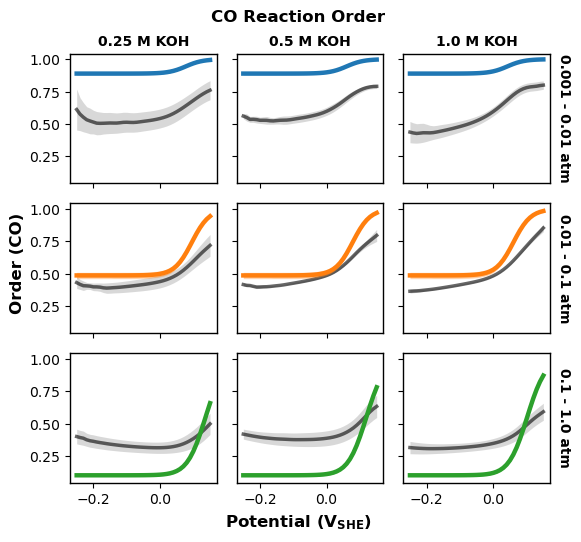

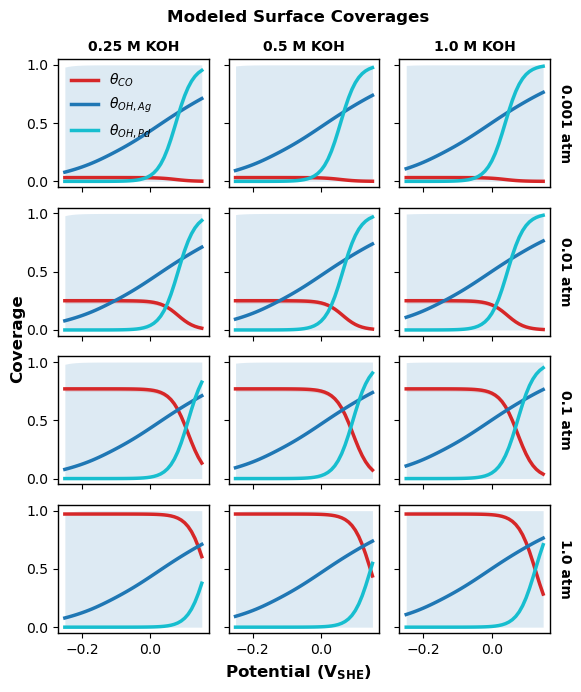

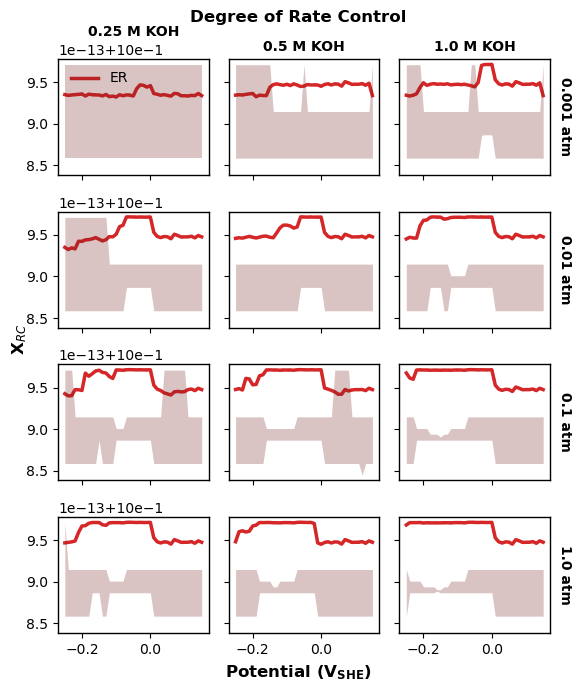

In [5]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)
plot_drc(ER_2, trace_ER_2, perturb_vars=['Gact2_0'], perturb_labels=['ER'])

# BF ER 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.31,7
,3000,0,0.39,15
,3000,0,0.33,7
,3000,0,0.37,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   373.08    58.07
p_loo       13.83        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



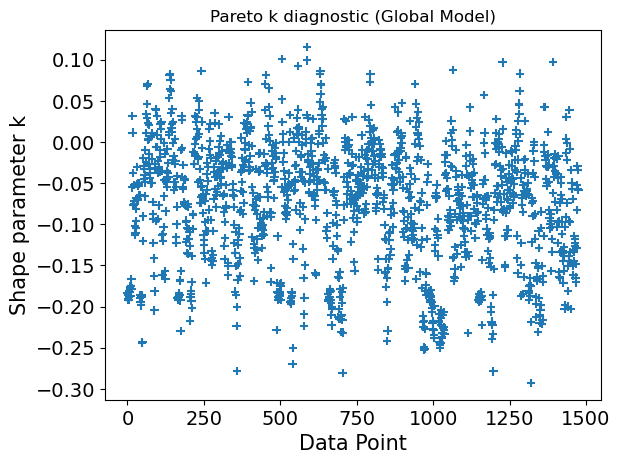

In [6]:
with pm.Model() as BF_ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER_2, loo_BF_ER_2 = fit_and_evaluate(BF_ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.077  0.001  -0.080   -0.075      0.000    0.000    1754.0    2231.0   1.00
deltaG4_0   0.084  0.003   0.078    0.089      0.000    0.000    1148.0    2074.0   1.00
deltaG5_0  -0.104  0.003  -0.110   -0.098      0.000    0.000    1912.0    2154.0   1.00
Gact2_BF_0  0.722  0.002   0.719    0.725      0.000    0.000     958.0    1691.0   1.01
Gact2_ER_0  0.716  0.001   0.713    0.718      0.000    0.000    1261.0    1958.0   1.00
beta_2      0.204  0.008   0.189    0.218      0.000    0.000    1027.0    1707.0   1.01
sigma_rel   0.227  0.011   0.208    0.248      0.000    0.000    2777.0    2917.0   1.00
sigma_base  0.039  0.002   0.034    0.043      0.000    0.000    2788.0    3291.0   1.00
exponent    2.285  0.095   2.097    2.456      0.002    0.001    3238.0    2830.0   1.00


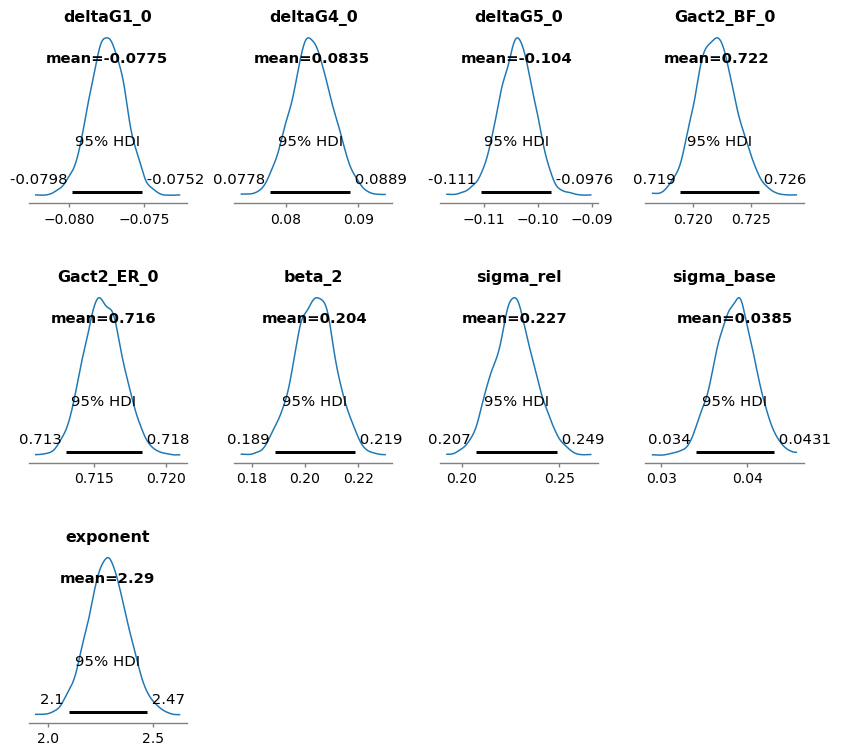

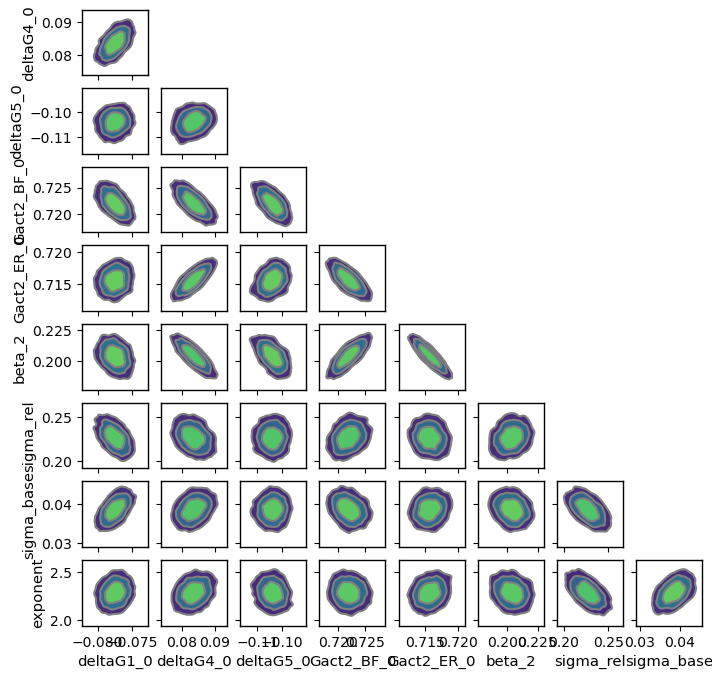

Sampling: [rate]


rate: 0.721


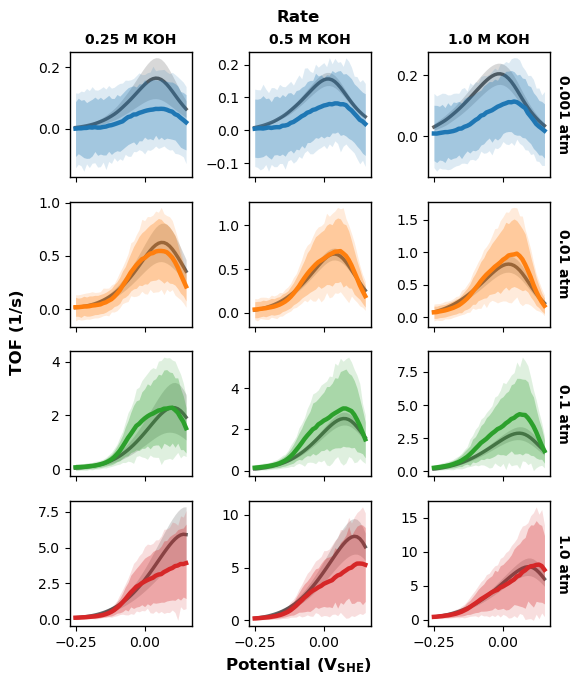

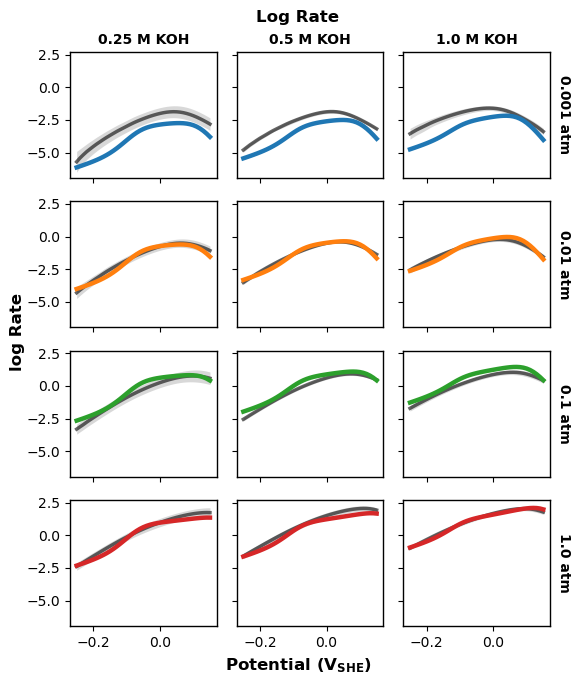

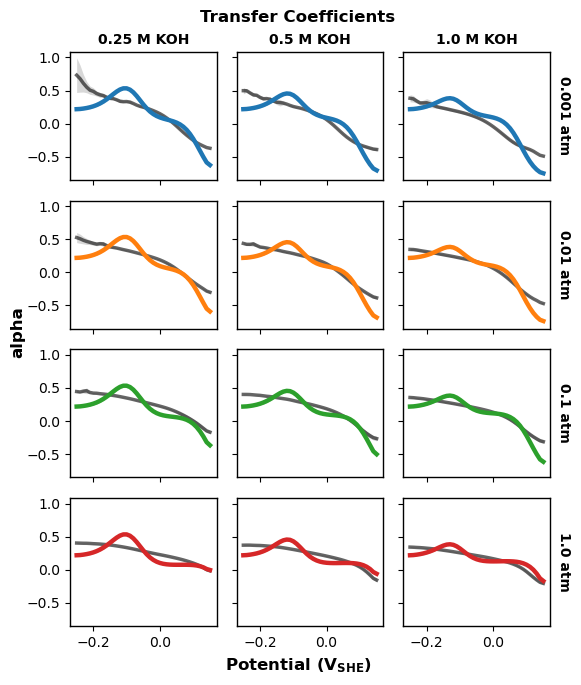

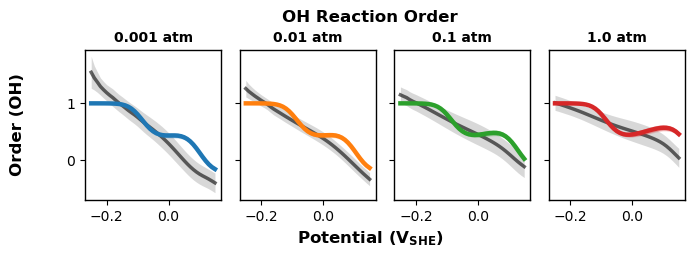

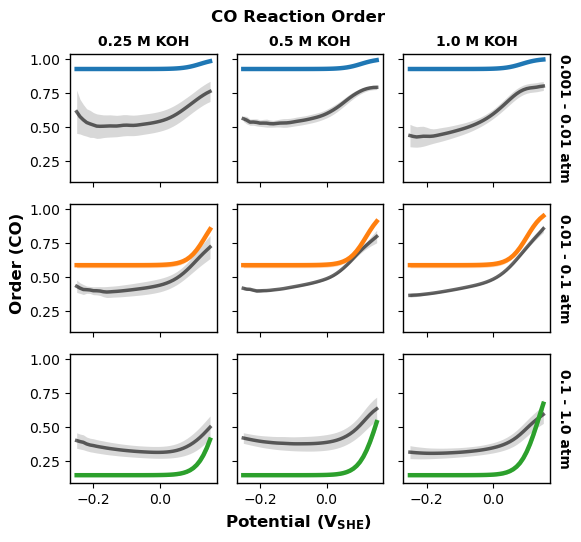

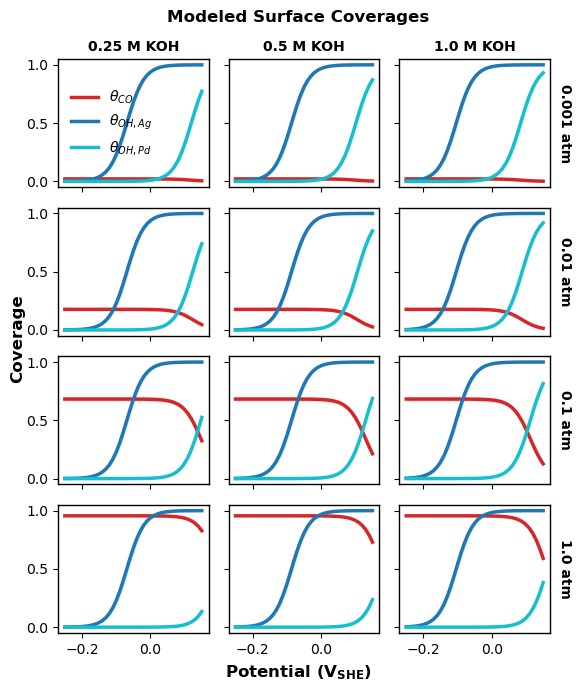

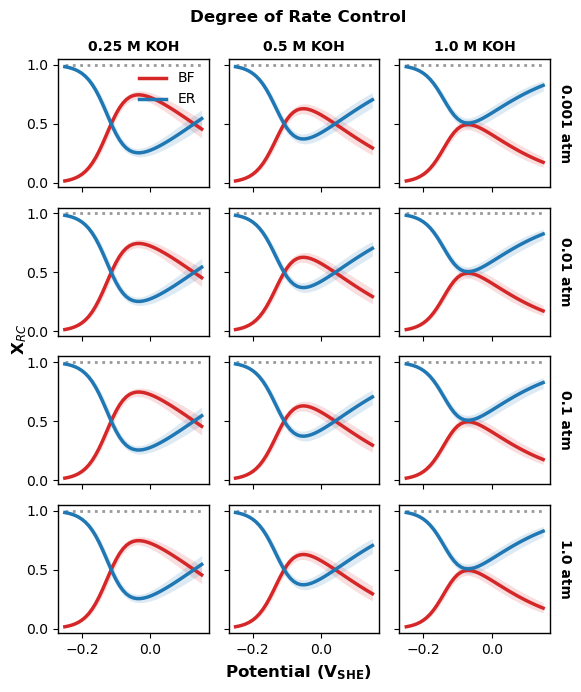

In [7]:
ppc_BF_ER_2 = plot_posteriors(trace_BF_ER_2, BF_ER_2)
plot_model_fits(trace_BF_ER_2, ppc_BF_ER_2); plot_coverages(trace_BF_ER_2)
plot_drc(BF_ER_2, trace_BF_ER_2, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# BF ER LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.32,15
,3000,0,0.31,31
,3000,0,0.35,15
,3000,0,0.39,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   390.86    57.88
p_loo       15.11        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



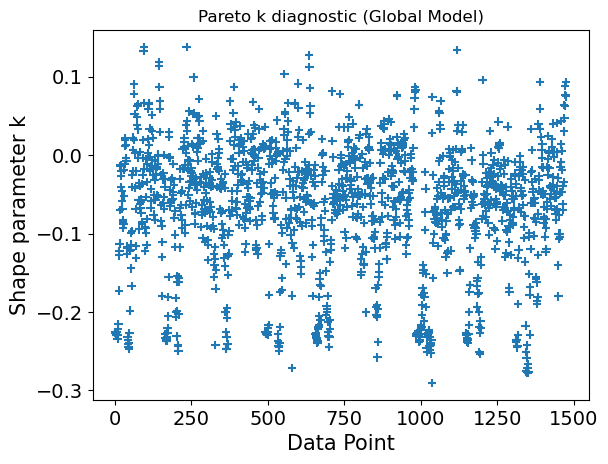

In [8]:
with pm.Model() as BF_ER_LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    2c. CO* + OH* -> COOH* + * (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_Pd = pm.Deterministic('theta_OH_Pd', pt.exp(log_theta_OH_Pd))
    theta_OH_Ag = pm.Deterministic('theta_OH_Ag', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    log_rate = pt.logsumexp(pt.stack([log_rate_BF, log_rate_ER, log_rate_LH]), axis=0)
    rate = observables(log_rate) 

trace_BF_ER_LH_2, loo_BF_ER_LH_2 = fit_and_evaluate(BF_ER_LH_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.077  0.001  -0.079   -0.075      0.000    0.000    2253.0    2880.0    1.0
deltaG4_0   0.067  0.003   0.062    0.073      0.000    0.000    1313.0    1715.0    1.0
deltaG5_0  -0.113  0.004  -0.120   -0.105      0.000    0.000    1603.0    1955.0    1.0
Gact2_BF_0  0.726  0.002   0.722    0.730      0.000    0.000    1033.0    1193.0    1.0
Gact2_ER_0  0.714  0.001   0.712    0.717      0.000    0.000    1231.0    1540.0    1.0
Gact2_LH_0  0.645  0.004   0.636    0.652      0.000    0.000    2515.0    1987.0    1.0
beta_2      0.213  0.007   0.199    0.226      0.000    0.000    1127.0    1368.0    1.0
sigma_rel   0.223  0.010   0.205    0.241      0.000    0.000    3374.0    3363.0    1.0
sigma_base  0.038  0.002   0.034    0.043      0.000    0.000    3366.0    3108.0    1.0
exponent    2.316  0.089   2.147    2.478      0.002    0.001    3477.0    3087.0    1.0


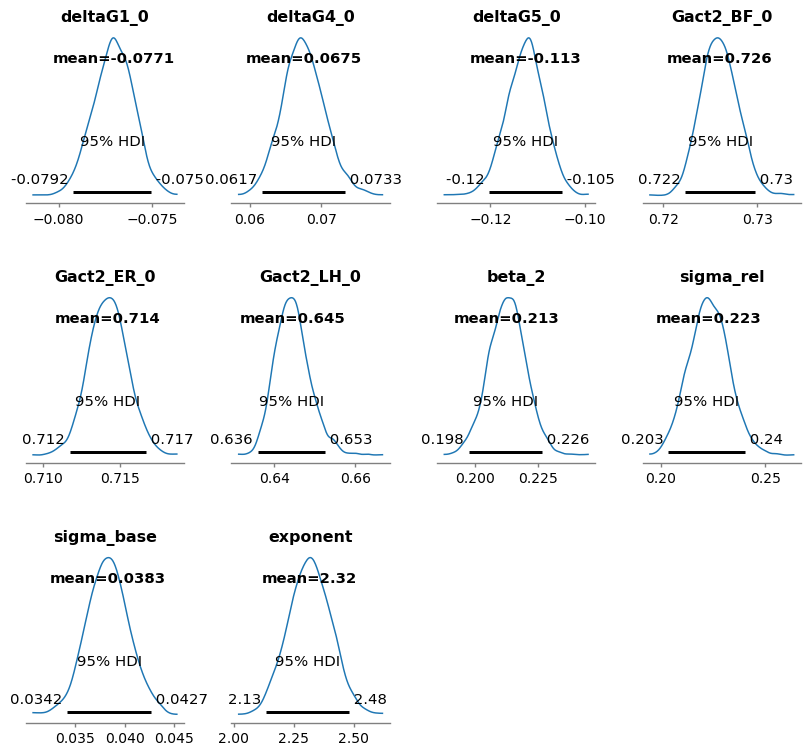

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


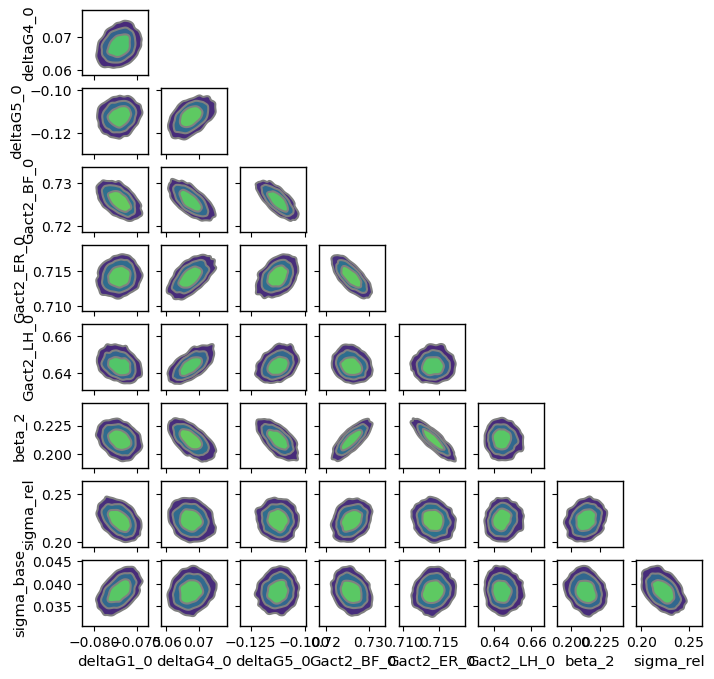

Sampling: [rate]


rate: 0.723


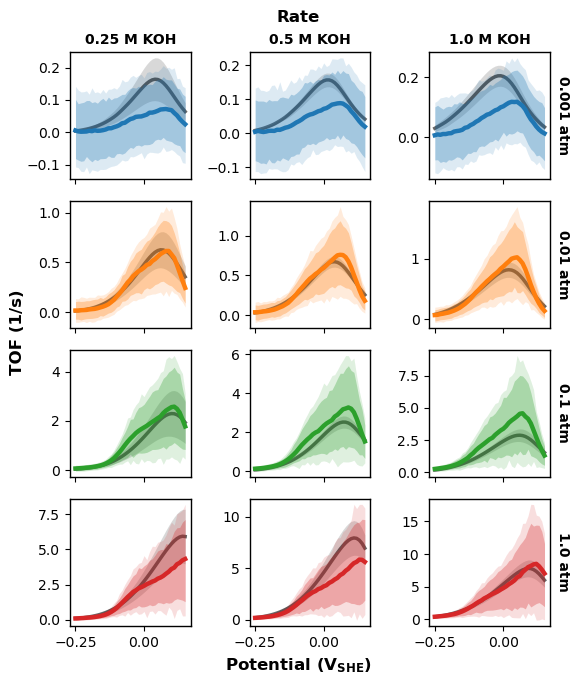

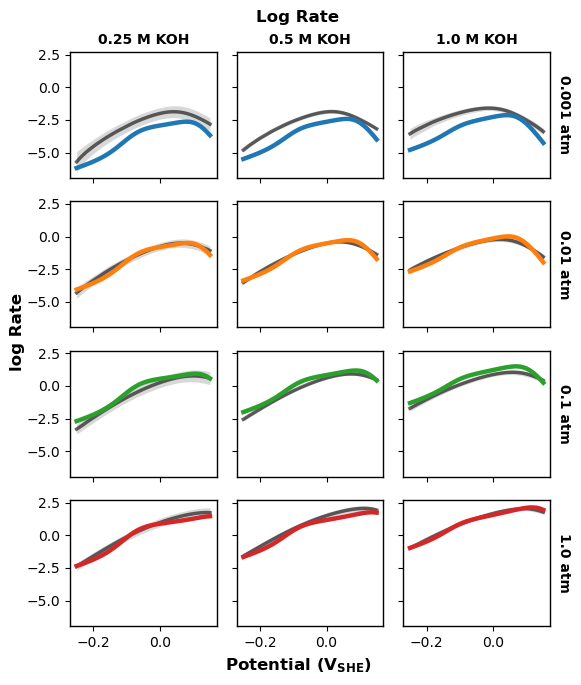

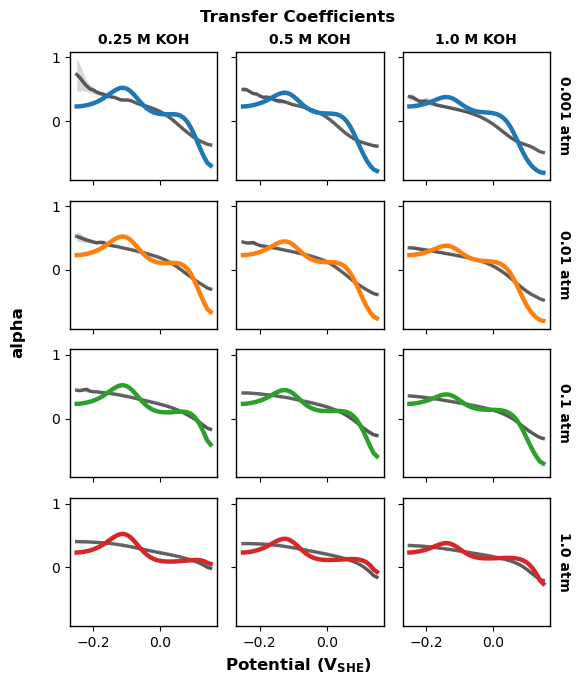

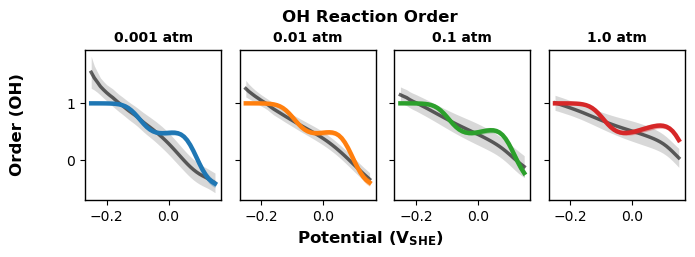

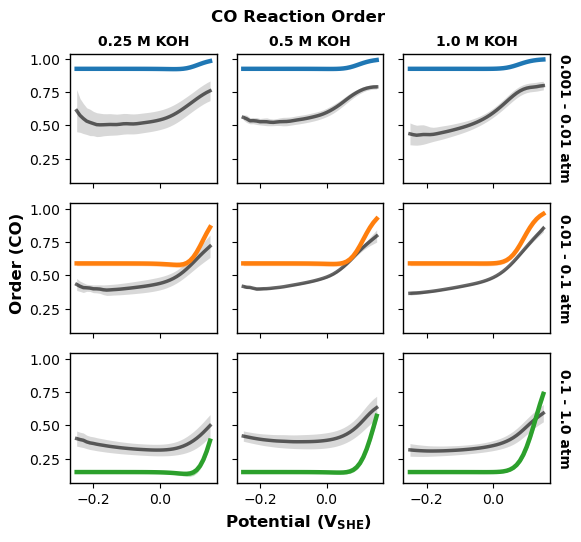

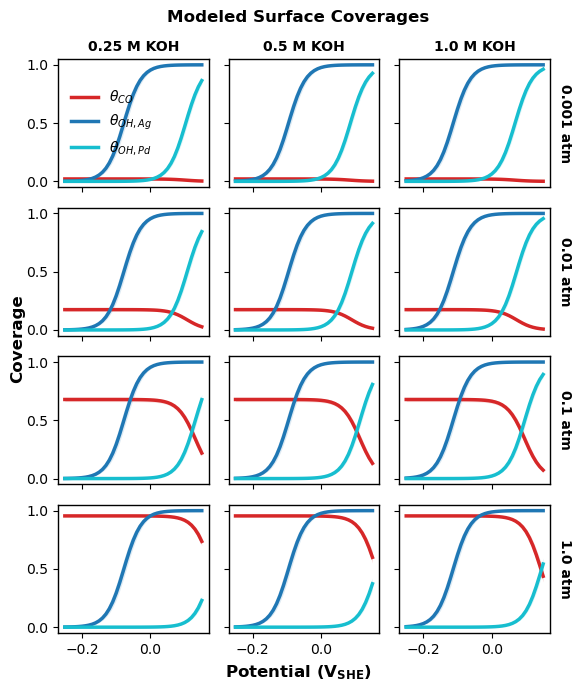

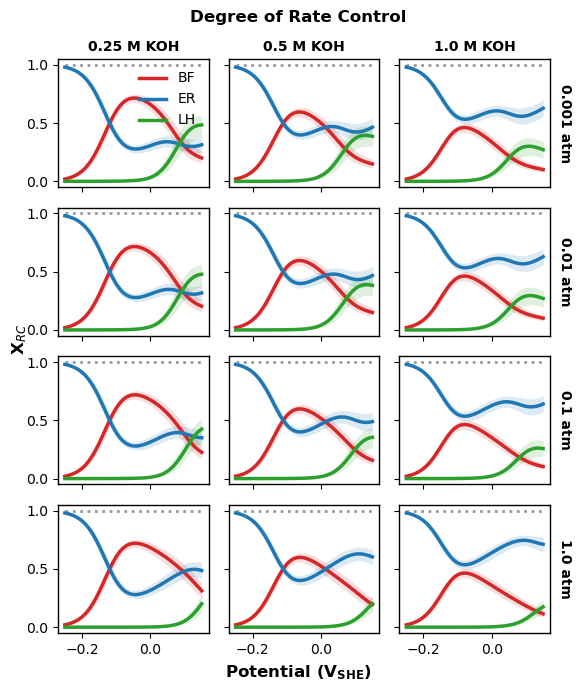

In [9]:
ppc_BF_ER_LH_2 = plot_posteriors(trace_BF_ER_LH_2, BF_ER_LH_2)
plot_model_fits(trace_BF_ER_LH_2, ppc_BF_ER_LH_2); plot_coverages(trace_BF_ER_LH_2)
plot_drc(BF_ER_LH_2, trace_BF_ER_LH_2, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0', 'Gact2_LH_0'], perturb_labels=['BF', 'ER', 'LH'])

# Comparison

            rank    elpd_loo      p_loo   elpd_diff        weight         se        dse  warning scale
BF_ER_LH_2     0  390.864018  15.106829    0.000000  7.038172e-01  57.876474   0.000000    False   log
BF_ER_2        1  373.081054  13.826674   17.782963  1.083415e-01  58.065430   7.758552    False   log
ER_2           2  162.686288   9.796314  228.177730  1.878413e-01  64.591625  29.087159    False   log
BF             3 -243.108544  14.080290  633.972562  8.621427e-10  60.648146  35.561200    False   log


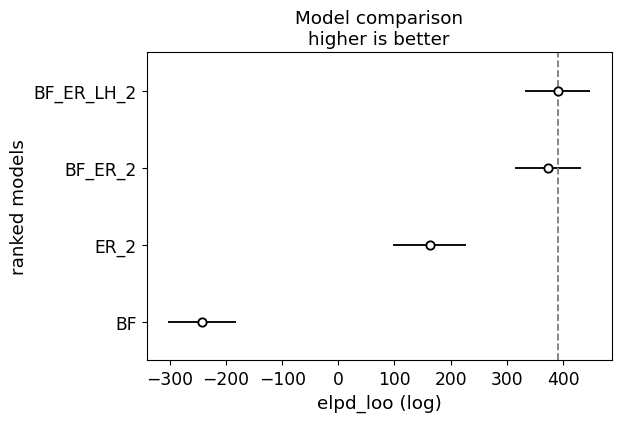

In [10]:
comparison_dict = {
    "BF": loo_BF,
    "ER_2": loo_ER_2,
    "BF_ER_2": loo_BF_ER_2,
    "BF_ER_LH_2": loo_BF_ER_LH_2
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()